## EXERCISE 1: Search of the best C

Create a SVM with linear kernel using the scikit-learn library.

Verify the performance with different values of the hyperparameter C using the function [logspace](https://numpy.org/doc/stable/reference/generated/numpy.logspace.html), nel range -20:0:20 (i.e., start=-20, stop = 0, num=20) on digits dataset.

> __QUESTION 1(a):__  Check the best configuration of C, using the 3-fold cross-validation on the digits dataset.

In [37]:
## SOL
from sklearn import svm
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np

digits_data = datasets.load_digits()

n_samples = len(digits_data.images)
X = digits_data.images.reshape((n_samples, -1))
y = digits_data.target
c_range = np.logspace(-20,0,20)
cv = GridSearchCV(svm.SVC(), param_grid={'C': c_range,'kernel':['linear']}, n_jobs=-1, cv=3)
cv.fit(X, y)
print("Best parameters set found on development set:")
print(cv.best_params_)
best_c = cv.best_params_['C']

Best parameters set found on development set:
{'C': np.float64(0.0006951927961775591), 'kernel': 'linear'}


> __QUESTION 1(b):__ Plot the score achieved in each configuration, by showing the different values for C in the x-axis and CV score in y-axis ((mean and standard deviation). Suggestion: Use the log-scale.

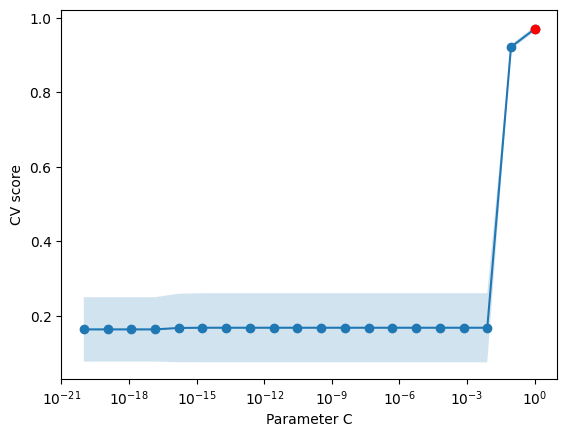

In [47]:
## SOL
import matplotlib.pyplot as plt

# get performance for each C
means = cv.cv_results_['mean_test_score']
stds = cv.cv_results_['std_test_score']
c_range = [p['C'] for p in cv.cv_results_['params']]

plt.figure()
plt.plot(c_range, means, marker='o')
plt.plot([best_c], [max(means)], marker='o',color='red')
plt.xscale('log')
plt.fill_between(
    c_range,
    np.array(means) - np.array(stds),
    np.array(means) + np.array(stds),
    alpha=0.2,
)
plt.ylabel("CV score")
plt.xlabel("Parameter C")
plt.show()

> __QUESTION 1(c):__ Train and test the model on the digits dataset with the best configuration found at the previous step


In [49]:
#SOL
from sklearn import metrics

svc = svm.SVC(**cv.best_params_)
svc.fit(X,y)
print(svc.score(X,y))

0.996661101836394


## EXERCISE 2: SVM on the iris_dataset

Load the iris dataset from the dataset available at this [link](https://scikit-learn.org/stable/datasets/toy_dataset.html).

In [54]:
# SOL 
import pandas as pd
import seaborn as sns

iris = datasets.load_iris()
data = iris.data
labels = iris.target


> __QUESTION 2(a):__  Verify the properties (number of samples, number of classes, etc.) of the dataset as we did during the lecture with the digit dataset.

Data shape:  (150, 4)
Classes:  [0 1 2] Counts:  [50 50 50]


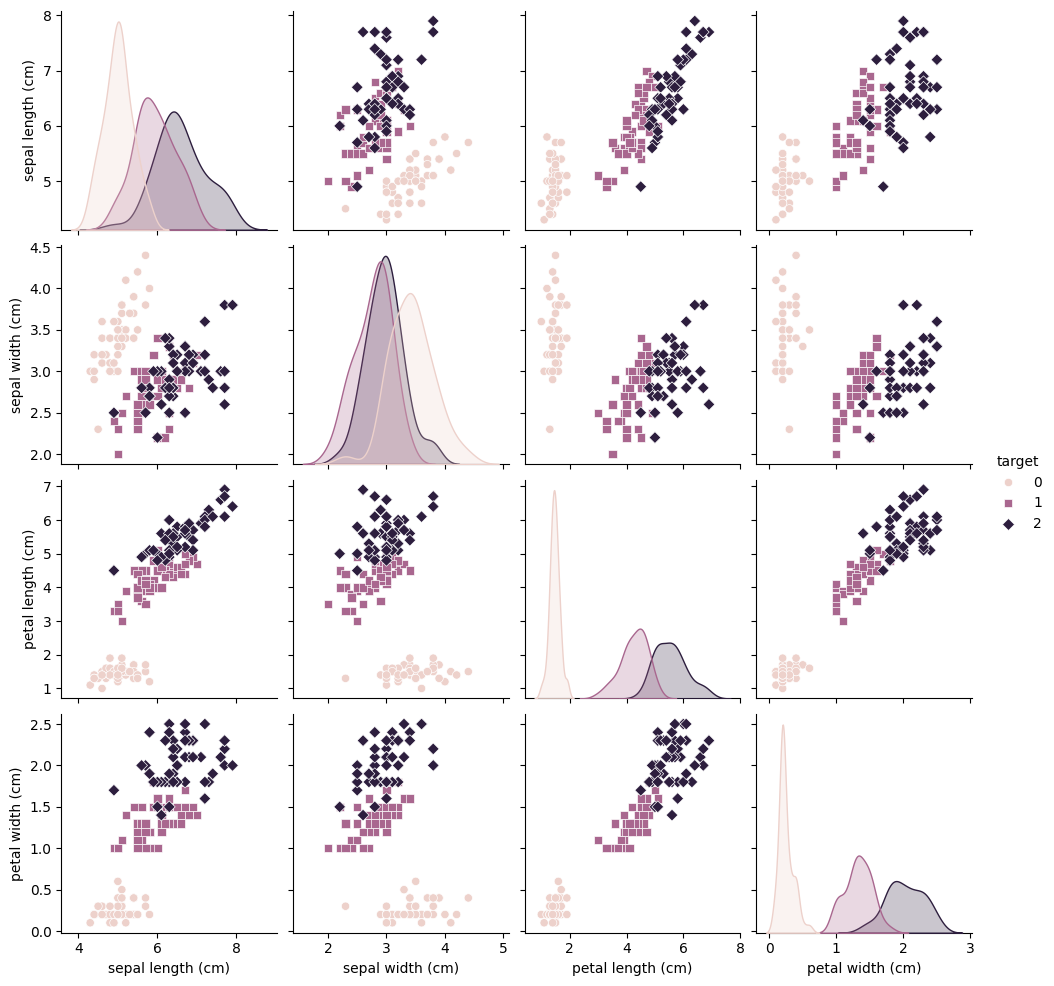

In [53]:
# SOL
print("Data shape: ", data.shape)
classes, counts = np.unique(labels,return_counts=True)
print("Classes: ", classes, "Counts: ", counts)

iris_df = pd.DataFrame(data, columns=iris.feature_names)
iris_df['target'] = labels

sns.pairplot(
    iris_df,
    hue="target",
    diag_kind="kde",
    markers=["o", "s", "D"],
)   

> __QUESTION 2(b):__ Split the dataset in training and test according to the following percentages: 70% - 30%

Train data shape:  (105, 4)
Test data shape:  (45, 4)


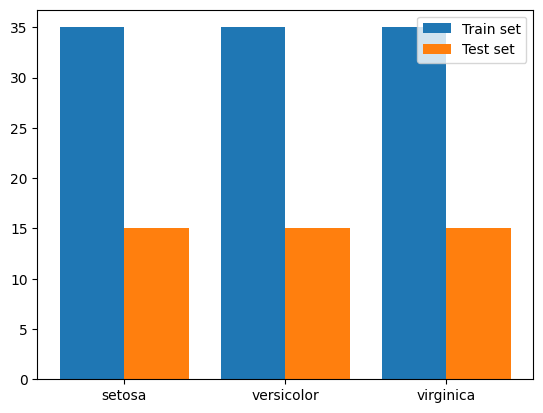

In [64]:
# SOL

from sklearn.model_selection import train_test_split
random_seed = None

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.3, random_state=random_seed,shuffle=True,stratify=labels)

print("Train data shape: ", X_train.shape)
print("Test data shape: ", X_test.shape)

train_classes,train_counts = np.unique(y_train,return_counts=True)
test_classes,test_counts = np.unique(y_test,return_counts=True)
plt.bar(train_classes-0.2,train_counts,width=0.4)
plt.bar(test_classes+0.2,test_counts,width=0.4)
plt.xticks(ticks=train_classes, labels=iris.target_names)
plt.legend(['Train set','Test set'])


> __QUESTION 2(c):__ Train a SVM with different kernel (linear, rbf, polinomial) by leaving the default values for the hyperparameters



In [65]:
# SOL 

from sklearn import svm
# 
kernels = ['linear','rbf','poly']

scores = []

models = [svm.SVC(kernel=kernel) for kernel in kernels]
for i,model in enumerate(models):
    model.fit(X_train, y_train)

> __QUESTION 2(d):__ Test the achieved models on the test set



Best kernel:  linear


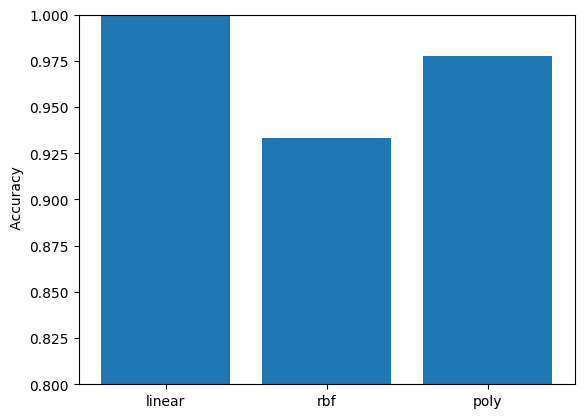

In [66]:
# SOL

scores = []
preds = []
for i,model in enumerate(models):
    y_pred = model.predict(X_test)
    preds.append(y_pred)
    scores.append((y_pred == y_test).mean())

plt.bar(kernels,scores)
plt.ylabel(" Accuracy")
plt.ylim(0.8,1)
best_kernel = kernels[np.argmax(scores)]
print("Best kernel: ", best_kernel) 

> __QUESTION 2(e):__ Represent the performances achieved for each kernel in the form of confusion matrix

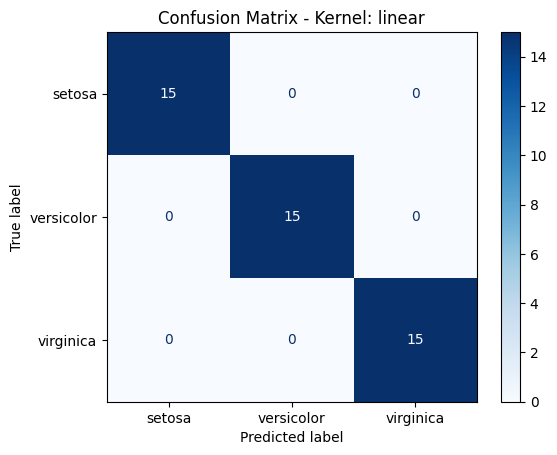

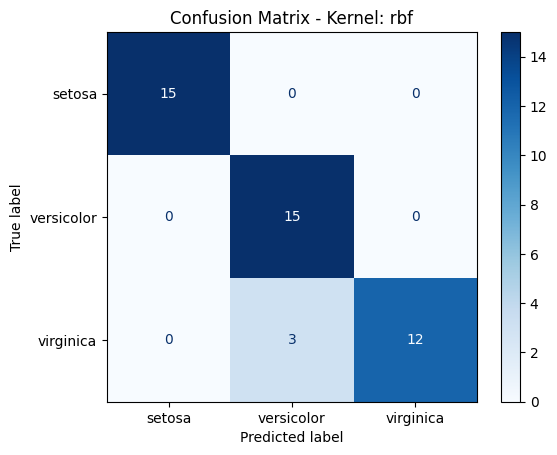

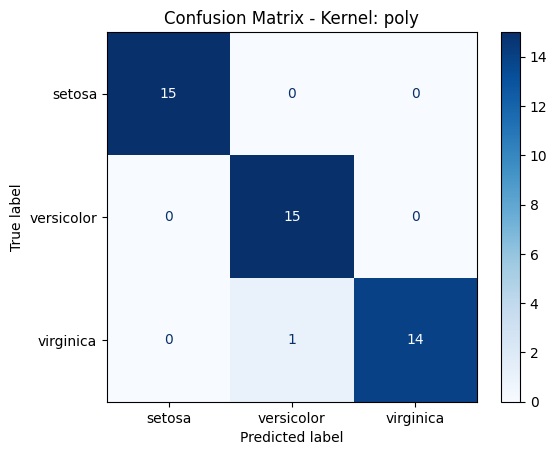

In [67]:
# SOL
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
for kernel,y_pred in zip(kernels,preds):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - Kernel: {kernel}')
    plt.show()
